![alt text](https://user-images.githubusercontent.com/76557164/176494819-d7be7cd7-a181-417b-aeee-b197c86a2a18.png)

=== Batch Normalization ===
=== Layer Normalization ===
=== Instance Normalization ===
=== Group Normalization ===

Batch Normalization PyTorch vs Custom:
Mean difference: 0.000000

Layer Normalization PyTorch vs Custom:
Mean difference: 0.000000

Instance Normalization PyTorch vs Custom:
Mean difference: 0.000000

Group Normalization PyTorch vs Custom:
Mean difference: 0.000000


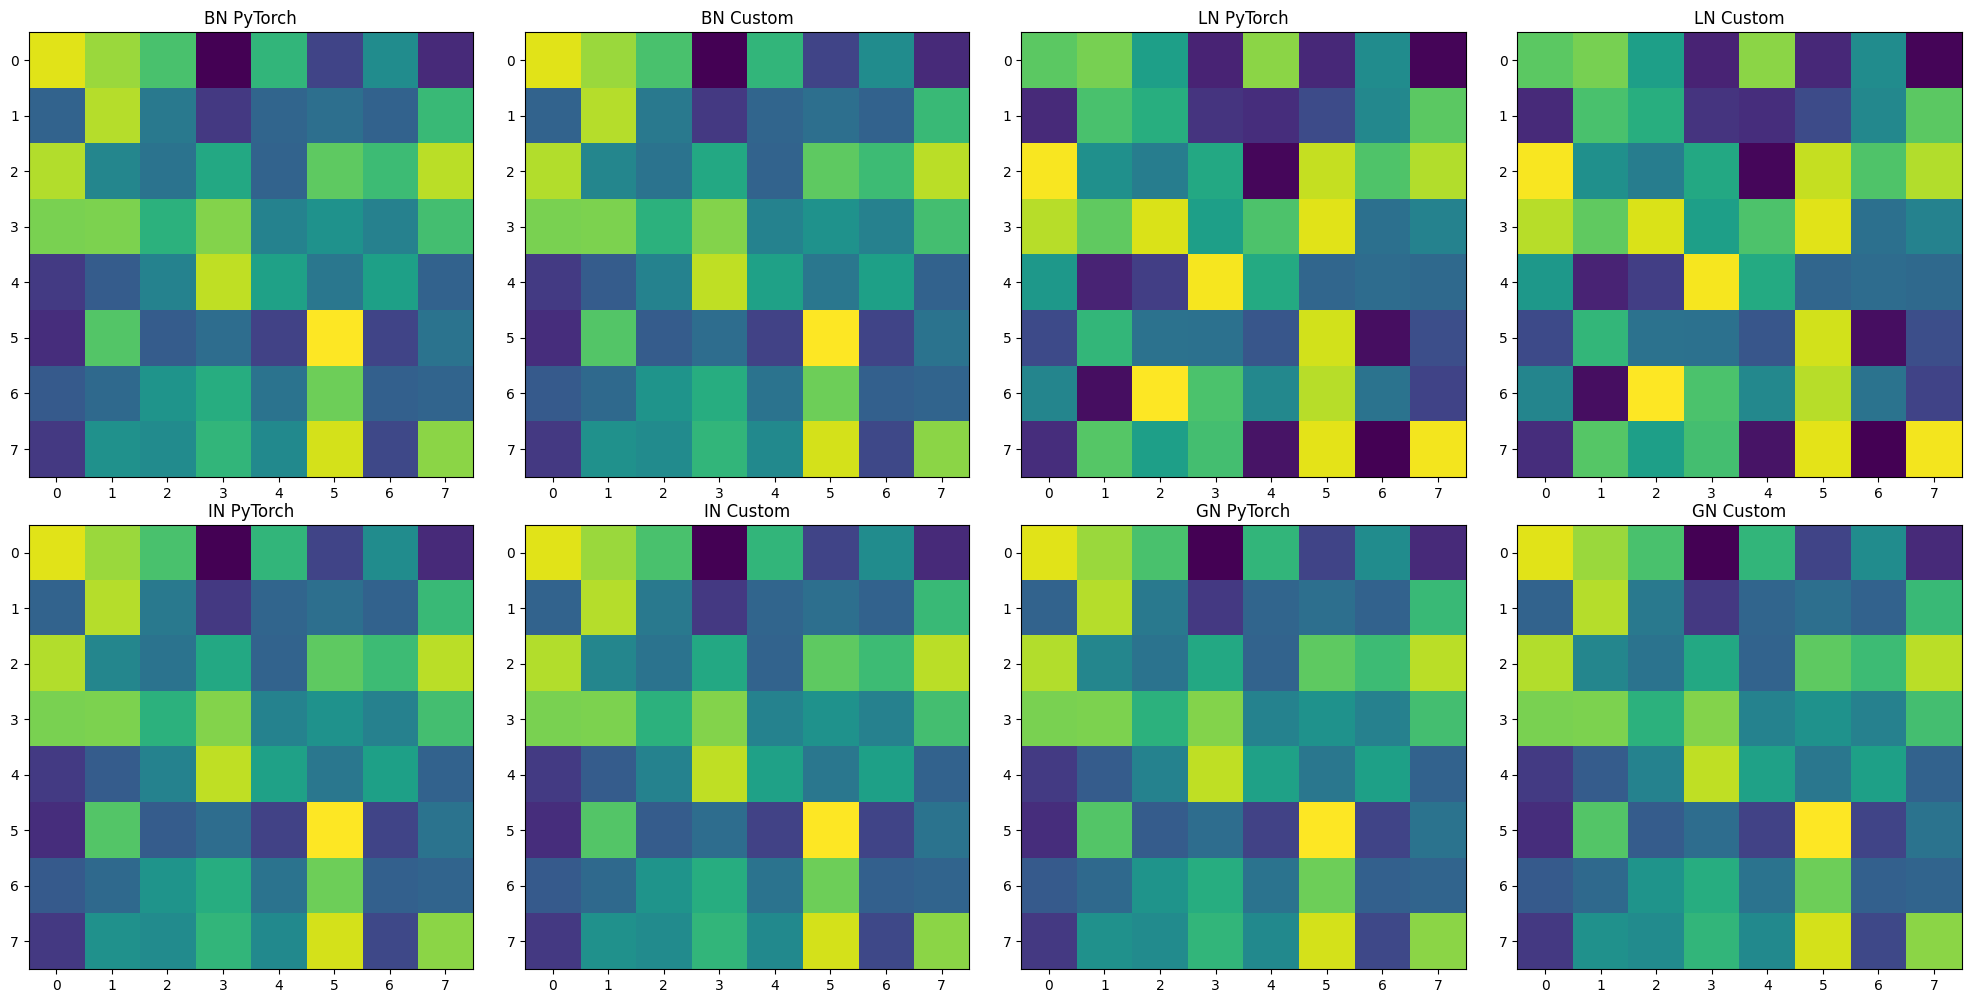

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility.
torch.manual_seed(42)

# Define a simple feature map for testing.
def create_test_data(batch_size=2, channels=3, height=4, width=4):
    """
    Create test data for normalization experiments.
    
    Args:
        batch_size: Number of samples in the batch.
        channels: Number of channels in each sample.
        height: Height of each feature map.
        width: Width of each feature map.
        
    Returns:
        A tensor of shape (batch_size, channels, height, width).
    """
    return torch.randn(batch_size, channels, height, width)

# 1. Batch Normalization
print("=== Batch Normalization ===")

# Using PyTorch's built-in implementation
class BatchNormPyTorch(nn.Module):
    """
    Batch Normalization using PyTorch's built-in implementation.
    """
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(BatchNormPyTorch, self).__init__()
        self.bn = nn.BatchNorm2d(num_features, eps=eps, momentum=momentum)
        
    def forward(self, x):
        return self.bn(x)

# Custom implementation of Batch Normalization
class BatchNormCustom(nn.Module):
    """
    Custom implementation of Batch Normalization.
    """
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(BatchNormCustom, self).__init__()
        self.eps = eps
        self.momentum = momentum
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))
        
    def forward(self, x):
        if self.training:
            # Calculate batch statistics.
            batch_mean = x.mean([0, 2, 3])  # Mean across batch, height, width.
            batch_var = x.var([0, 2, 3], unbiased=False)  # Variance across batch, height, width.
            
            # Update running statistics.
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * batch_var
            
            # Normalize using batch statistics.
            x_normalized = (x - batch_mean.view(1, -1, 1, 1)) / torch.sqrt(batch_var.view(1, -1, 1, 1) + self.eps)
        else:
            # Normalize using running statistics.
            x_normalized = (x - self.running_mean.view(1, -1, 1, 1)) / torch.sqrt(self.running_var.view(1, -1, 1, 1) + self.eps)
        
        # Apply scale and shift.
        return self.gamma.view(1, -1, 1, 1) * x_normalized + self.beta.view(1, -1, 1, 1)

# 2. Layer Normalization
print("=== Layer Normalization ===")

# Using PyTorch's built-in implementation
class LayerNormPyTorch(nn.Module):
    """
    Layer Normalization using PyTorch's built-in implementation.
    """
    def __init__(self, normalized_shape):
        super(LayerNormPyTorch, self).__init__()
        self.ln = nn.LayerNorm(normalized_shape)
        
    def forward(self, x):
        # Reshape for LayerNorm which expects (N, *) shape.
        batch_size, channels, height, width = x.shape
        x_reshaped = x.permute(0, 2, 3, 1).contiguous().view(batch_size, height * width, channels)
        x_normalized = self.ln(x_reshaped)
        # Reshape back to original shape.
        return x_normalized.view(batch_size, height, width, channels).permute(0, 3, 1, 2)

# Custom implementation of Layer Normalization
class LayerNormCustom(nn.Module):
    """
    Custom implementation of Layer Normalization.
    """
    def __init__(self, normalized_shape, eps=1e-5):
        super(LayerNormCustom, self).__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(normalized_shape))
        self.beta = nn.Parameter(torch.zeros(normalized_shape))
        
    def forward(self, x):
        # Reshape for layer normalization.
        batch_size, channels, height, width = x.shape
        x_reshaped = x.permute(0, 2, 3, 1).contiguous()
        
        # Calculate mean and variance along the channel dimension.
        mean = x_reshaped.mean(dim=-1, keepdim=True)
        var = x_reshaped.var(dim=-1, keepdim=True, unbiased=False)
        
        # Normalize.
        x_normalized = (x_reshaped - mean) / torch.sqrt(var + self.eps)
        
        # Apply scale and shift.
        x_normalized = self.gamma * x_normalized + self.beta
        
        # Reshape back to original shape.
        return x_normalized.permute(0, 3, 1, 2)

# 3. Instance Normalization
print("=== Instance Normalization ===")

# Using PyTorch's built-in implementation
class InstanceNormPyTorch(nn.Module):
    """
    Instance Normalization using PyTorch's built-in implementation.
    """
    def __init__(self, num_features, eps=1e-5):
        super(InstanceNormPyTorch, self).__init__()
        self.in_norm = nn.InstanceNorm2d(num_features, eps=eps)
        
    def forward(self, x):
        return self.in_norm(x)

# Custom implementation of Instance Normalization
class InstanceNormCustom(nn.Module):
    """
    Custom implementation of Instance Normalization.
    """
    def __init__(self, num_features, eps=1e-5):
        super(InstanceNormCustom, self).__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))
        
    def forward(self, x):
        # Calculate mean and variance for each instance across spatial dimensions.
        mean = x.mean(dim=[2, 3], keepdim=True)
        var = x.var(dim=[2, 3], keepdim=True, unbiased=False)
        
        # Normalize.
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        
        # Apply scale and shift.
        return self.gamma.view(1, -1, 1, 1) * x_normalized + self.beta.view(1, -1, 1, 1)

# 4. Group Normalization
print("=== Group Normalization ===")

# Using PyTorch's built-in implementation
class GroupNormPyTorch(nn.Module):
    """
    Group Normalization using PyTorch's built-in implementation.
    """
    def __init__(self, num_groups, num_channels, eps=1e-5):
        super(GroupNormPyTorch, self).__init__()
        self.gn = nn.GroupNorm(num_groups, num_channels, eps=eps)
        
    def forward(self, x):
        return self.gn(x)

# Custom implementation of Group Normalization
class GroupNormCustom(nn.Module):
    """
    Custom implementation of Group Normalization.
    """
    def __init__(self, num_groups, num_channels, eps=1e-5):
        super(GroupNormCustom, self).__init__()
        self.num_groups = num_groups
        self.num_channels = num_channels
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(num_channels))
        self.beta = nn.Parameter(torch.zeros(num_channels))
        
    def forward(self, x):
        batch_size, channels, height, width = x.shape
        
        # Reshape to separate groups.
        x_reshaped = x.view(batch_size, self.num_groups, -1)
        
        # Calculate mean and variance for each group.
        mean = x_reshaped.mean(dim=2, keepdim=True)
        var = x_reshaped.var(dim=2, keepdim=True, unbiased=False)
        
        # Normalize.
        x_normalized = (x_reshaped - mean) / torch.sqrt(var + self.eps)
        
        # Reshape back.
        x_normalized = x_normalized.view(batch_size, channels, height, width)
        
        # Apply scale and shift.
        return self.gamma.view(1, -1, 1, 1) * x_normalized + self.beta.view(1, -1, 1, 1)

# Test all normalization methods
def test_normalizations():
    """
    Test all normalization methods and compare results.
    """
    # Create test data.
    batch_size = 2
    channels = 4
    height = width = 8
    x = create_test_data(batch_size, channels, height, width)
    
    # Test Batch Normalization.
    bn_pytorch = BatchNormPyTorch(channels)
    bn_custom = BatchNormCustom(channels)
    
    # Test Layer Normalization.
    ln_pytorch = LayerNormPyTorch([channels])
    ln_custom = LayerNormCustom([channels])
    
    # Test Instance Normalization.
    in_pytorch = InstanceNormPyTorch(channels)
    in_custom = InstanceNormCustom(channels)
    
    # Test Group Normalization.
    num_groups = 2
    gn_pytorch = GroupNormPyTorch(num_groups, channels)
    gn_custom = GroupNormCustom(num_groups, channels)
    
    # Set all modules to training mode.
    for module in [bn_pytorch, bn_custom, ln_pytorch, ln_custom, in_pytorch, in_custom, gn_pytorch, gn_custom]:
        module.train()
    
    # Forward pass.
    bn_pytorch_out = bn_pytorch(x)
    bn_custom_out = bn_custom(x)
    ln_pytorch_out = ln_pytorch(x)
    ln_custom_out = ln_custom(x)
    in_pytorch_out = in_pytorch(x)
    in_custom_out = in_custom(x)
    gn_pytorch_out = gn_pytorch(x)
    gn_custom_out = gn_custom(x)
    
    # Print results.
    print("\nBatch Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(bn_pytorch_out - bn_custom_out).abs().mean().item():.6f}")
    
    print("\nLayer Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(ln_pytorch_out - ln_custom_out).abs().mean().item():.6f}")
    
    print("\nInstance Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(in_pytorch_out - in_custom_out).abs().mean().item():.6f}")
    
    print("\nGroup Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(gn_pytorch_out - gn_custom_out).abs().mean().item():.6f}")
    
    # Visualize the first channel of the first sample.
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    
    axs[0, 0].imshow(bn_pytorch_out[0, 0].detach().numpy())
    axs[0, 0].set_title("BN PyTorch")
    
    axs[0, 1].imshow(bn_custom_out[0, 0].detach().numpy())
    axs[0, 1].set_title("BN Custom")
    
    axs[0, 2].imshow(ln_pytorch_out[0, 0].detach().numpy())
    axs[0, 2].set_title("LN PyTorch")
    
    axs[0, 3].imshow(ln_custom_out[0, 0].detach().numpy())
    axs[0, 3].set_title("LN Custom")
    
    axs[1, 0].imshow(in_pytorch_out[0, 0].detach().numpy())
    axs[1, 0].set_title("IN PyTorch")
    
    axs[1, 1].imshow(in_custom_out[0, 0].detach().numpy())
    axs[1, 1].set_title("IN Custom")
    
    axs[1, 2].imshow(gn_pytorch_out[0, 0].detach().numpy())
    axs[1, 2].set_title("GN PyTorch")
    
    axs[1, 3].imshow(gn_custom_out[0, 0].detach().numpy())
    axs[1, 3].set_title("GN Custom")
    
    plt.tight_layout()
    plt.show()

# Run the test.
test_normalizations()


=== Batch Normalization for NLP ===
=== Layer Normalization for NLP ===
=== Instance Normalization for NLP ===
=== Group Normalization for NLP ===
=== RMSNorm for NLP ===

Batch Normalization PyTorch vs Custom:
Mean difference: 0.000000

Layer Normalization PyTorch vs Custom:
Mean difference: 0.000000

Instance Normalization PyTorch vs Custom:
Mean difference: 0.000000

Group Normalization PyTorch vs Custom:
Mean difference: 0.000000


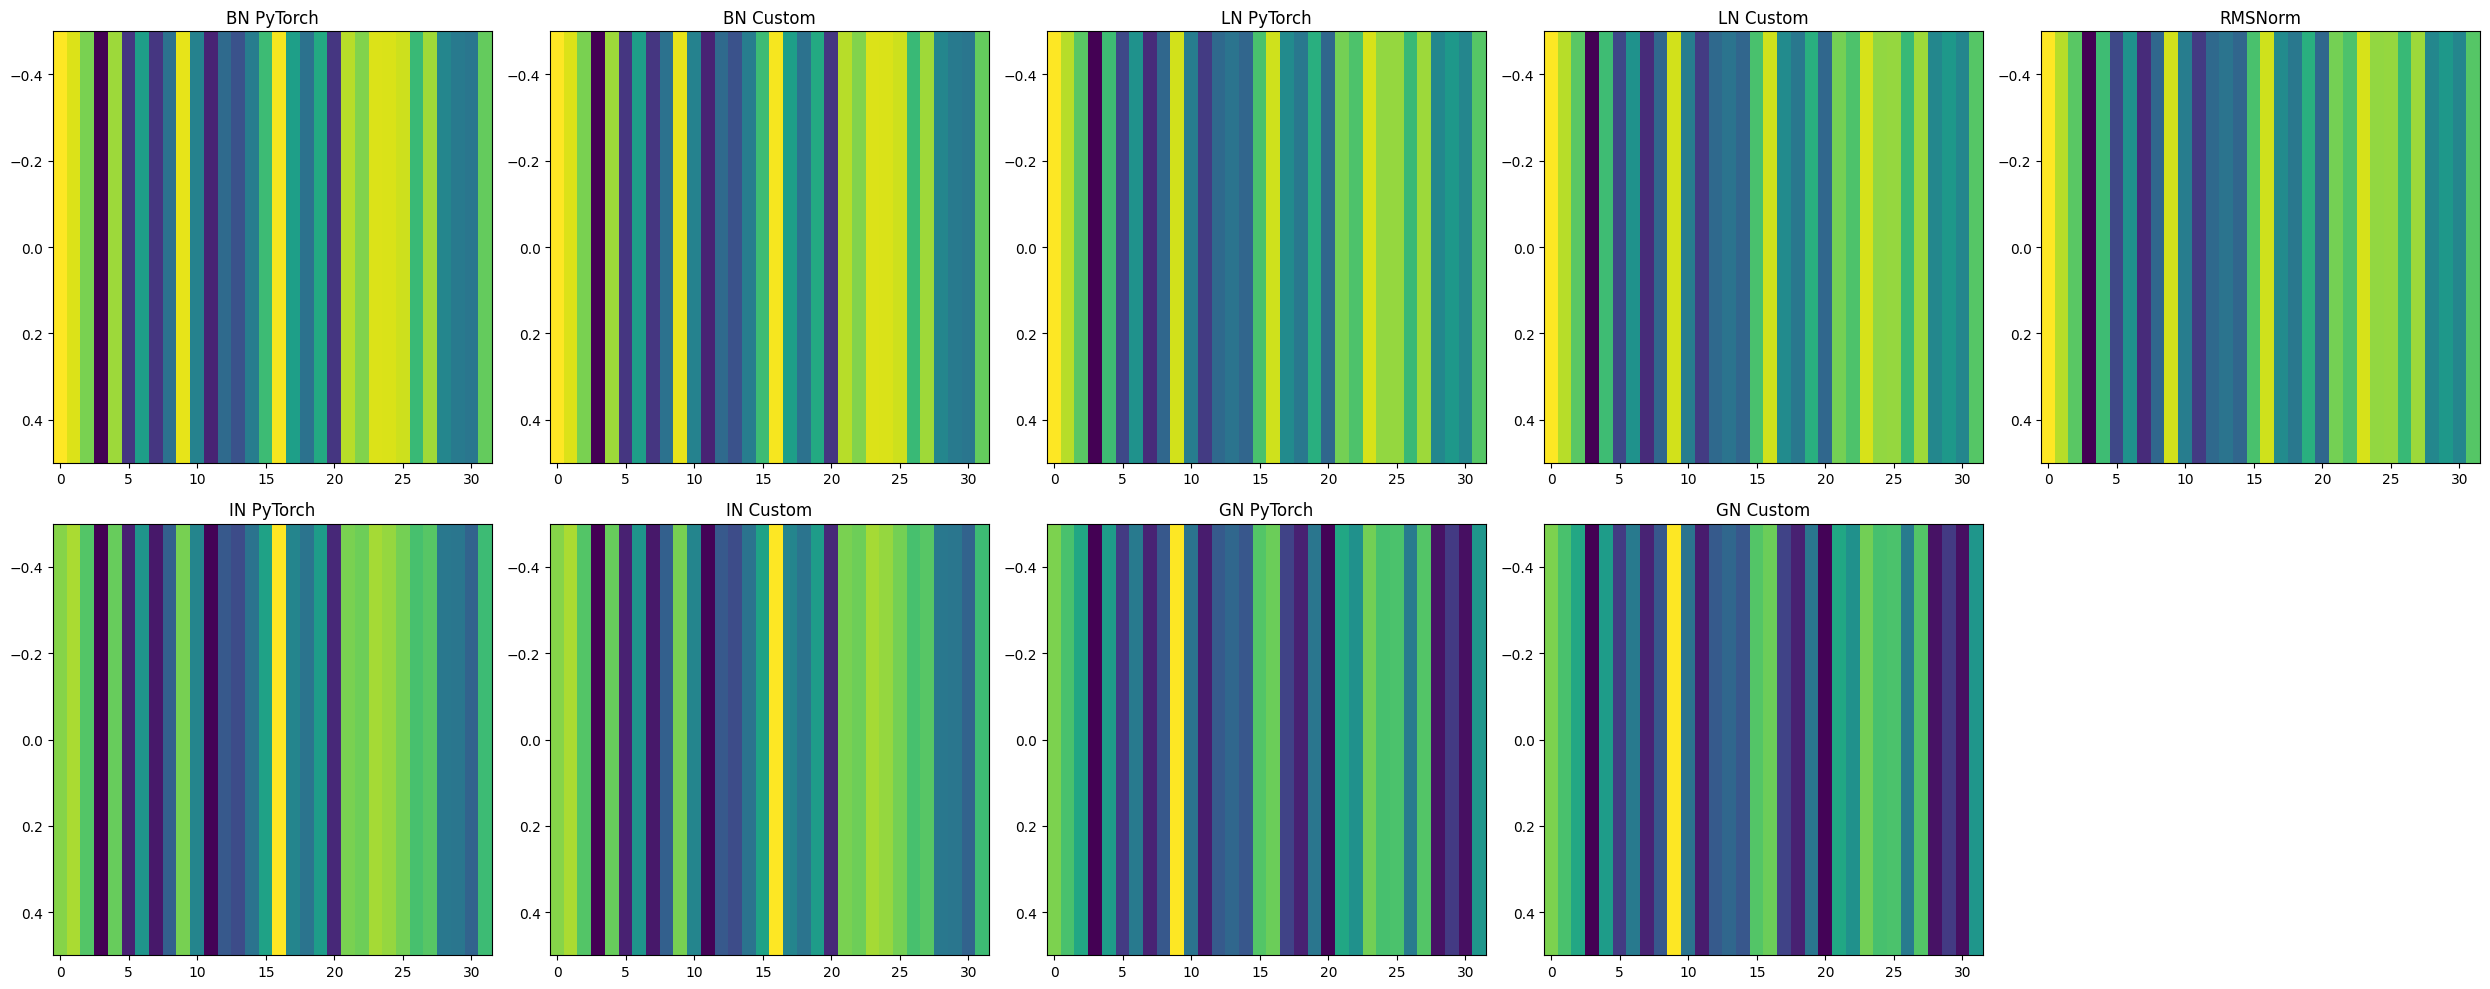

In [4]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility.
torch.manual_seed(42)

# Define a simple feature map for testing.
def create_test_data(batch_size=2, seq_len=16, hidden_size=32):
    """
    Create test data for normalization experiments in NLP context.
    
    Args:
        batch_size: Number of samples in the batch.
        seq_len: Length of the sequence.
        hidden_size: Dimension of the hidden features.
        
    Returns:
        A tensor of shape (batch_size, seq_len, hidden_size).
    """
    return torch.randn(batch_size, seq_len, hidden_size)

# 1. Batch Normalization
print("=== Batch Normalization for NLP ===")

# Using PyTorch's built-in implementation
class BatchNormPyTorch(nn.Module):
    """
    Batch Normalization using PyTorch's built-in implementation for NLP.
    """
    def __init__(self, hidden_size, eps=1e-5, momentum=0.1):
        super(BatchNormPyTorch, self).__init__()
        self.bn = nn.BatchNorm1d(hidden_size, eps=eps, momentum=momentum)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        # BatchNorm1d expects: [batch_size, hidden_size, seq_len]
        x = x.permute(0, 2, 1)
        x = self.bn(x)
        # Return to original shape
        return x.permute(0, 2, 1)

# Custom implementation of Batch Normalization
class BatchNormCustom(nn.Module):
    """
    Custom implementation of Batch Normalization for NLP.
    """
    def __init__(self, hidden_size, eps=1e-5, momentum=0.1):
        super(BatchNormCustom, self).__init__()
        self.eps = eps
        self.momentum = momentum
        self.gamma = nn.Parameter(torch.ones(hidden_size))
        self.beta = nn.Parameter(torch.zeros(hidden_size))
        self.register_buffer('running_mean', torch.zeros(hidden_size))
        self.register_buffer('running_var', torch.ones(hidden_size))
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        if self.training:
            # Calculate batch statistics across batch and sequence dimensions.
            batch_mean = x.mean([0, 1])  # Mean across batch and sequence.
            batch_var = x.var([0, 1], unbiased=False)  # Variance across batch and sequence.
            
            # Update running statistics.
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * batch_var
            
            # Normalize using batch statistics.
            x_normalized = (x - batch_mean.view(1, 1, -1)) / torch.sqrt(batch_var.view(1, 1, -1) + self.eps)
        else:
            # Normalize using running statistics.
            x_normalized = (x - self.running_mean.view(1, 1, -1)) / torch.sqrt(self.running_var.view(1, 1, -1) + self.eps)
        
        # Apply scale and shift.
        return self.gamma.view(1, 1, -1) * x_normalized + self.beta.view(1, 1, -1)

# 2. Layer Normalization
print("=== Layer Normalization for NLP ===")

# Using PyTorch's built-in implementation
class LayerNormPyTorch(nn.Module):
    """
    Layer Normalization using PyTorch's built-in implementation for NLP.
    """
    def __init__(self, hidden_size, eps=1e-5):
        super(LayerNormPyTorch, self).__init__()
        self.ln = nn.LayerNorm(hidden_size, eps=eps)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        return self.ln(x)

# Custom implementation of Layer Normalization
class LayerNormCustom(nn.Module):
    """
    Custom implementation of Layer Normalization for NLP.
    """
    def __init__(self, hidden_size, eps=1e-5):
        super(LayerNormCustom, self).__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(hidden_size))
        self.beta = nn.Parameter(torch.zeros(hidden_size))
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        # Calculate mean and variance along the last dimension (hidden_size).
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        
        # Normalize.
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        
        # Apply scale and shift.
        return self.gamma * x_normalized + self.beta

# 3. Instance Normalization (for NLP, this is per-sequence normalization)
print("=== Instance Normalization for NLP ===")

# Using PyTorch's built-in implementation adapted for NLP
class InstanceNormPyTorch(nn.Module):
    """
    Instance Normalization using PyTorch's built-in implementation adapted for NLP.
    """
    def __init__(self, hidden_size, eps=1e-5):
        super(InstanceNormPyTorch, self).__init__()
        self.in_norm = nn.InstanceNorm1d(hidden_size, eps=eps, affine=True)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        # InstanceNorm1d expects: [batch_size, hidden_size, seq_len]
        x = x.permute(0, 2, 1)
        x = self.in_norm(x)
        # Return to original shape
        return x.permute(0, 2, 1)

# Custom implementation of Instance Normalization
class InstanceNormCustom(nn.Module):
    """
    Custom implementation of Instance Normalization for NLP.
    """
    def __init__(self, hidden_size, eps=1e-5):
        super(InstanceNormCustom, self).__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(hidden_size))
        self.beta = nn.Parameter(torch.zeros(hidden_size))
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        # Calculate mean and variance for each sequence across hidden dimension.
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, keepdim=True, unbiased=False)
        
        # Normalize.
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        
        # Apply scale and shift.
        return self.gamma.view(1, 1, -1) * x_normalized + self.beta.view(1, 1, -1)

# 4. Group Normalization (adapted for NLP)
print("=== Group Normalization for NLP ===")

# Using PyTorch's built-in implementation adapted for NLP
class GroupNormPyTorch(nn.Module):
    """
    Group Normalization using PyTorch's built-in implementation adapted for NLP.
    """
    def __init__(self, num_groups, hidden_size, eps=1e-5):
        super(GroupNormPyTorch, self).__init__()
        self.gn = nn.GroupNorm(num_groups, hidden_size, eps=eps)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        batch_size, seq_len, hidden_size = x.shape
        # GroupNorm expects: [batch_size * seq_len, hidden_size, 1]
        x = x.reshape(-1, hidden_size, 1)
        x = self.gn(x)
        # Return to original shape
        return x.reshape(batch_size, seq_len, hidden_size)

# Custom implementation of Group Normalization
class GroupNormCustom(nn.Module):
    """
    Custom implementation of Group Normalization for NLP.
    """
    def __init__(self, num_groups, hidden_size, eps=1e-5):
        super(GroupNormCustom, self).__init__()
        self.num_groups = num_groups
        self.hidden_size = hidden_size
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(hidden_size))
        self.beta = nn.Parameter(torch.zeros(hidden_size))
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        batch_size, seq_len, hidden_size = x.shape
        
        # Reshape to separate groups.
        x_reshaped = x.reshape(batch_size * seq_len, self.num_groups, -1)
        
        # Calculate mean and variance for each group.
        mean = x_reshaped.mean(dim=2, keepdim=True)
        var = x_reshaped.var(dim=2, keepdim=True, unbiased=False)
        
        # Normalize.
        x_normalized = (x_reshaped - mean) / torch.sqrt(var + self.eps)
        
        # Reshape back.
        x_normalized = x_normalized.reshape(batch_size, seq_len, hidden_size)
        
        # Apply scale and shift.
        return self.gamma.view(1, 1, -1) * x_normalized + self.beta.view(1, 1, -1)

# 5. RMSNorm (commonly used in Transformers)
print("=== RMSNorm for NLP ===")

class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization.
    """
    def __init__(self, hidden_size, eps=1e-8):
        super(RMSNorm, self).__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(hidden_size))
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, hidden_size]
        # Calculate RMS.
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        x_normalized = x / rms
        
        # Apply scale.
        return self.weight * x_normalized

# Test all normalization methods for NLP
def test_nlp_normalizations():
    """
    Test all normalization methods for NLP and compare results.
    """
    # Create test data.
    batch_size = 2
    seq_len = 16
    hidden_size = 32
    x = create_test_data(batch_size, seq_len, hidden_size)
    
    # Test Batch Normalization.
    bn_pytorch = BatchNormPyTorch(hidden_size)
    bn_custom = BatchNormCustom(hidden_size)
    
    # Test Layer Normalization.
    ln_pytorch = LayerNormPyTorch(hidden_size)
    ln_custom = LayerNormCustom(hidden_size)
    
    # Test Instance Normalization.
    in_pytorch = InstanceNormPyTorch(hidden_size)
    in_custom = InstanceNormCustom(hidden_size)
    
    # Test Group Normalization.
    num_groups = 4
    gn_pytorch = GroupNormPyTorch(num_groups, hidden_size)
    gn_custom = GroupNormCustom(num_groups, hidden_size)
    
    # Test RMSNorm.
    rms_norm = RMSNorm(hidden_size)
    
    # Set all modules to training mode.
    for module in [bn_pytorch, bn_custom, ln_pytorch, ln_custom, in_pytorch, in_custom, gn_pytorch, gn_custom, rms_norm]:
        module.train()
    
    # Forward pass.
    bn_pytorch_out = bn_pytorch(x)
    bn_custom_out = bn_custom(x)
    ln_pytorch_out = ln_pytorch(x)
    ln_custom_out = ln_custom(x)
    in_pytorch_out = in_pytorch(x)
    in_custom_out = in_custom(x)
    gn_pytorch_out = gn_pytorch(x)
    gn_custom_out = gn_custom(x)
    rms_norm_out = rms_norm(x)
    
    # Print results.
    print("\nBatch Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(bn_pytorch_out - bn_custom_out).abs().mean().item():.6f}")
    
    print("\nLayer Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(ln_pytorch_out - ln_custom_out).abs().mean().item():.6f}")
    
    print("\nInstance Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(in_pytorch_out - in_custom_out).abs().mean().item():.6f}")
    
    print("\nGroup Normalization PyTorch vs Custom:")
    print(f"Mean difference: {(gn_pytorch_out - gn_custom_out).abs().mean().item():.6f}")
    
    # Visualize the first token embedding of the first sample.
    fig, axs = plt.subplots(2, 5, figsize=(25, 10))
    
    # Helper function to plot embeddings
    def plot_embedding(ax, data, title):
        im = ax.imshow(data.detach().numpy().reshape(1, -1), aspect='auto', cmap='viridis')
        ax.set_title(title)
        return im
    
    plot_embedding(axs[0, 0], bn_pytorch_out[0, 0], "BN PyTorch")
    plot_embedding(axs[0, 1], bn_custom_out[0, 0], "BN Custom")
    plot_embedding(axs[0, 2], ln_pytorch_out[0, 0], "LN PyTorch")
    plot_embedding(axs[0, 3], ln_custom_out[0, 0], "LN Custom")
    plot_embedding(axs[0, 4], rms_norm_out[0, 0], "RMSNorm")
    
    plot_embedding(axs[1, 0], in_pytorch_out[0, 0], "IN PyTorch")
    plot_embedding(axs[1, 1], in_custom_out[0, 0], "IN Custom")
    plot_embedding(axs[1, 2], gn_pytorch_out[0, 0], "GN PyTorch")
    plot_embedding(axs[1, 3], gn_custom_out[0, 0], "GN Custom")
    
    # Add a colorbar
    # fig.colorbar(im, ax=axs[1, 4])
    axs[1, 4].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the test for NLP normalizations.
test_nlp_normalizations()
